In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import relu,softmax
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data,columns = iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
df['target'] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [5]:
for i in iris.target_names:
    print(i)

setosa
versicolor
virginica


In [6]:
def names(x):
    if x == 0:
        return "setosa"
    if x == 1:
        return "versicolor"
    if x == 2:
        return "virginica"
df['target_names'] = df.target.apply(names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [30]:
x = df.drop(['target','target_names'],axis = 'columns')
y = df['target']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)
mm = MinMaxScaler()
x_train_minmax = mm.fit_transform(x_train)
x_test_minmax = mm.transform(x_test)
model1 = Sequential([
    Dense(16,activation = 'relu',input_shape=(4,)),
    Dense(8,activation = 'relu'),
    Dense(4,activation = 'relu'),
    Dense(3,activation = 'softmax')
])

model1.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history1 = model1.fit(x_train_minmax,y_train,epochs = 100,batch_size = 32,validation_split = 0.2,callbacks=EarlyStopping())

Epoch 1/100


C:\Users\Shibam\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.1146 - loss: 1.0986 - val_accuracy: 0.0833 - val_loss: 1.1086
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2500 - loss: 1.0949 - val_accuracy: 0.2083 - val_loss: 1.1044
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3750 - loss: 1.0902 - val_accuracy: 0.2083 - val_loss: 1.1000
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4062 - loss: 1.0864 - val_accuracy: 0.3750 - val_loss: 1.0951
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4271 - loss: 1.0821 - val_accuracy: 0.3750 - val_loss: 1.0908
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4792 - loss: 1.0786 - val_accuracy: 0.4167 - val_loss: 1.0852
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5000 - loss: 1.0748 - val_accuracy: 0.4167 - val_loss: 1.0821
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5312 - loss: 1.0723 - val_accuracy: 0.5000 - val_loss: 1.0783
Epoc

In [37]:
x = df.drop(['target','target_names'],axis = 'columns')
y = df['target']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)
ss = StandardScaler()
x_train_scaled = ss.fit_transform(x_train)
x_test_scaled = ss.transform(x_test)
model2 = Sequential([
    Dense(16,activation = 'relu',input_shape=(4,)),
    Dense(8,activation = 'relu'),
    Dense(4,activation = 'relu'),
    Dense(3,activation = 'softmax')
])

model2.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history2 = model2.fit(x_train_scaled,y_train,epochs = 100,batch_size = 32,validation_split = 0.2,callbacks=EarlyStopping())

Epoch 1/100


C:\Users\Shibam\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.5104 - loss: 1.0860 - val_accuracy: 0.4583 - val_loss: 1.1335
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 1.0614 - val_accuracy: 0.5000 - val_loss: 1.1151
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5104 - loss: 1.0402 - val_accuracy: 0.5000 - val_loss: 1.0976
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5208 - loss: 1.0222 - val_accuracy: 0.5000 - val_loss: 1.0812
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5104 - loss: 1.0062 - val_accuracy: 0.5417 - val_loss: 1.0657
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5312 - loss: 0.9918 - val_accuracy: 0.5833 - val_loss: 1.0494
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5312 - loss: 0.9795 - val_accuracy: 0.5833 - val_loss: 1.0335
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5521 - loss: 0.9669 - val_accuracy: 0.6667 - val_loss: 1.0170
Epoc

In [38]:
test_loss, test_accuracy = model1.evaluate(x_test_minmax, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9333 - loss: 0.5804
Test Loss: 0.5803683400154114
Test Accuracy: 0.9333333373069763


In [39]:
test_loss, test_accuracy = model2.evaluate(x_test_scaled, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9667 - loss: 0.1441
Test Loss: 0.14409668743610382
Test Accuracy: 0.9666666388511658


In [33]:
print("Training Accuracy :", history1.history['accuracy'][-1])
print("Validation Accuracy :", history1.history['val_accuracy'][-1])

print("Training Loss :", history1.history['loss'][-1])
print("Validation Loss :", history1.history['val_loss'][-1])

Training Accuracy : 0.9270833134651184
Validation Accuracy : 0.875
Training Loss : 0.5950726270675659
Validation Loss : 0.676705539226532


In [40]:
print("Training Accuracy :", history2.history['accuracy'][-1])
print("Validation Accuracy :", history2.history['val_accuracy'][-1])

print("Training Loss :", history2.history['loss'][-1])
print("Validation Loss :", history2.history['val_loss'][-1])

Training Accuracy : 0.9583333134651184
Validation Accuracy : 0.9583333134651184
Training Loss : 0.18365295231342316
Validation Loss : 0.20668816566467285


In [41]:
#Such as Model2 is not overfitted
predictions = model2.predict(x_test_scaled)
print(predictions[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
[0.03360371 0.7507428  0.21565352]


In [42]:
predicted_classes = np.argmax(predictions,axis = 1)

In [43]:
print("Predicted:", predicted_classes[:10])
print("Actual   :", y_test[:10].values if hasattr(y_test, "values") else y_test[:10])

Predicted: [1 0 2 1 1 0 1 2 1 1]
Actual   : [1 0 2 1 1 0 1 2 1 1]


In [44]:
cm = confusion_matrix(y_test,predicted_classes)

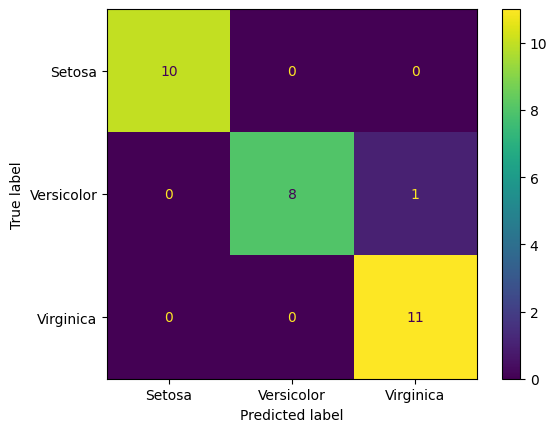

In [47]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Setosa', 'Versicolor', 'Virginica']
)

disp.plot()
plt.show()

In [48]:
print(classification_report(y_test, predicted_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

